# 🧭 Objective
To recommend sensible dosage ranges for cyanide (CN) and dissolved oxygen (DO) based on historically observed recovery outcomes.

### Data-Driven Advisory Interface (without prediction)
Instead of predicting outcomes, this tool will **summarise historical trends** to:
* Recommend a **range of CN and DO concentrations** that historically resulted in good recoveries
* Flag **zones of inefficiency**, e.g. high CN/DO usage with poor recovery
* Show **interactive plots** to explore trade-offs (e.g. more CN vs better recovery)

### 🧱 Interface Components
You could implement this in your existing React frontend or Jupyter dashboard. Key features:
**1. Recommended Range Table**
| Metric                 | Sensible Range (based on data) |
| ---------------------- | ------------------------------ |
| CN Concentration (ppm) | 180–240                        |
| DO Concentration (ppm) | 6.5–8.5                        |
| Recovery (%)           | 89–94                          |

These ranges should be data-driven using quantiles or clustering.

**2. Interactive Heatmap**
* X-axis: CN (ppm)
* Y-axis: DO (ppm)
* **Colour**: Median or 75th percentile recovery
* Tooltip shows count of samples and average recovery

This shows where Shanta has historically operated most effectively.

**3. Slider Filters for Ore Conditions**
Add controls for:
* Gold grade
* Fines
* Tank type (e.g. Leach vs CIL)

Allow filtering to isolate different ore types or operating conditions.

**4. Inefficiency Flags**
Highlight areas where:
* CN > 240 ppm and recovery < 85%
* DO > 9 ppm with no recovery improvement
This gives context to avoid wasteful scenarios.

**5. Example Panel – "Based on Similar Past Conditions"**
When current CN/DO values are entered (or ranges selected), show:
> "In similar conditions (n=24), recovery ranged from 90.3% to 92.8% with CN between 190–210 ppm and DO between 7.2–8.1 ppm."

## Concept

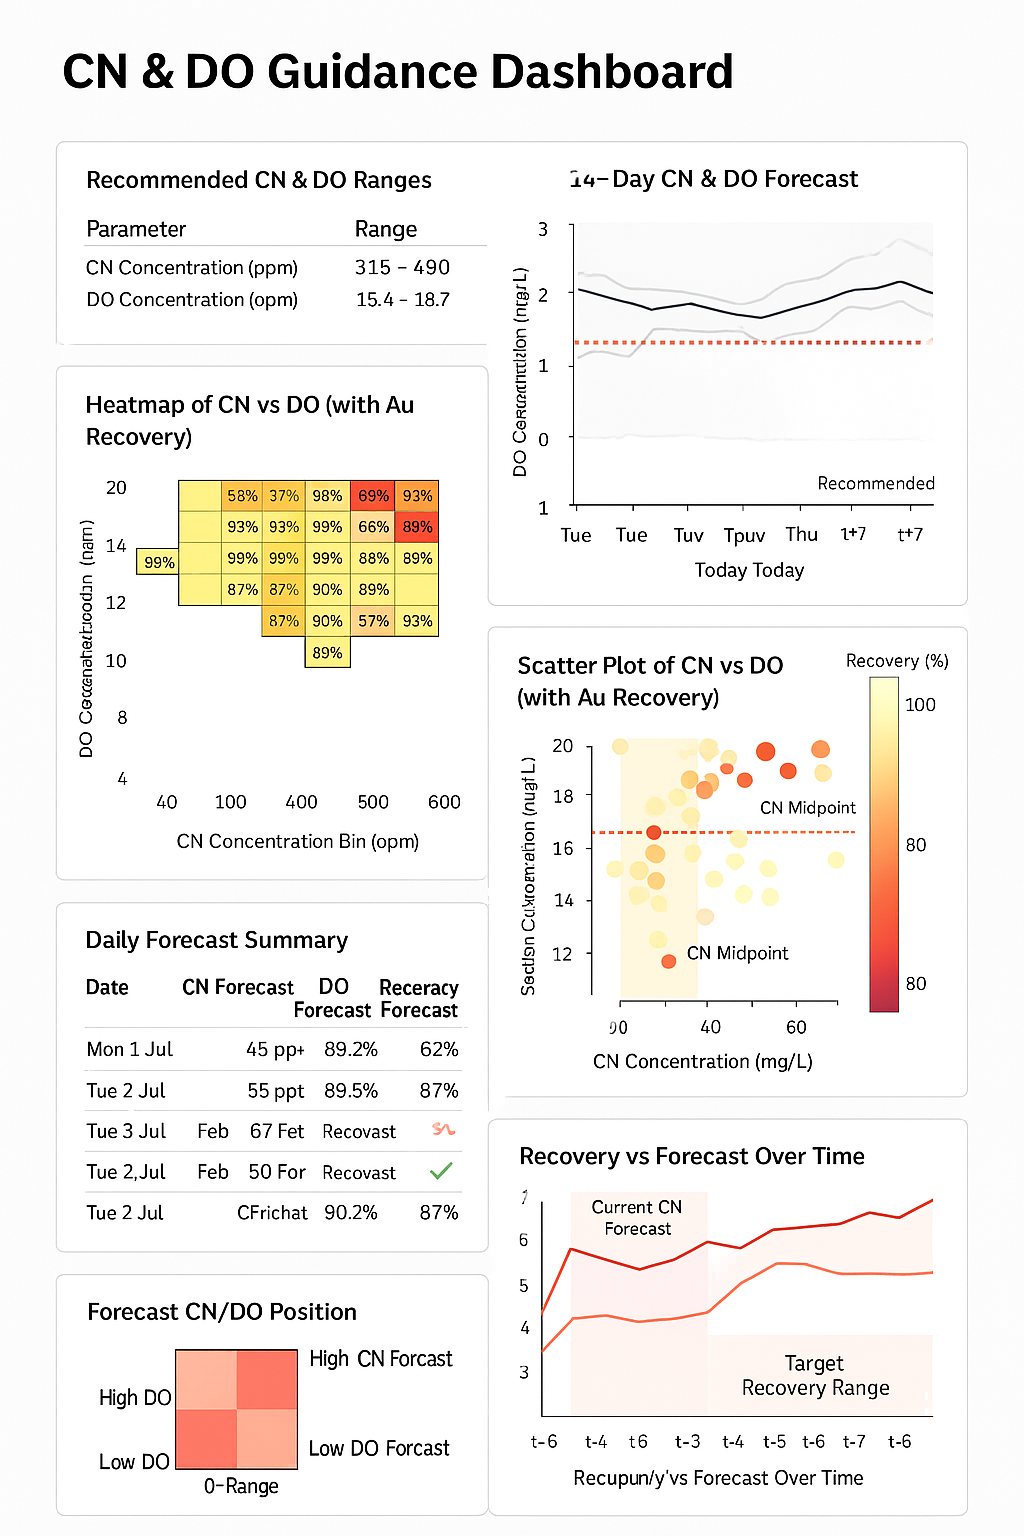

## Load Data

In [1]:
import pandas as pd
import numpy as np

# Load and parse
df = pd.read_csv('site_leaching_data_processed.csv')
df["Date"] = pd.to_datetime(df["Date"])

## Matplot & Seaborn Implementation

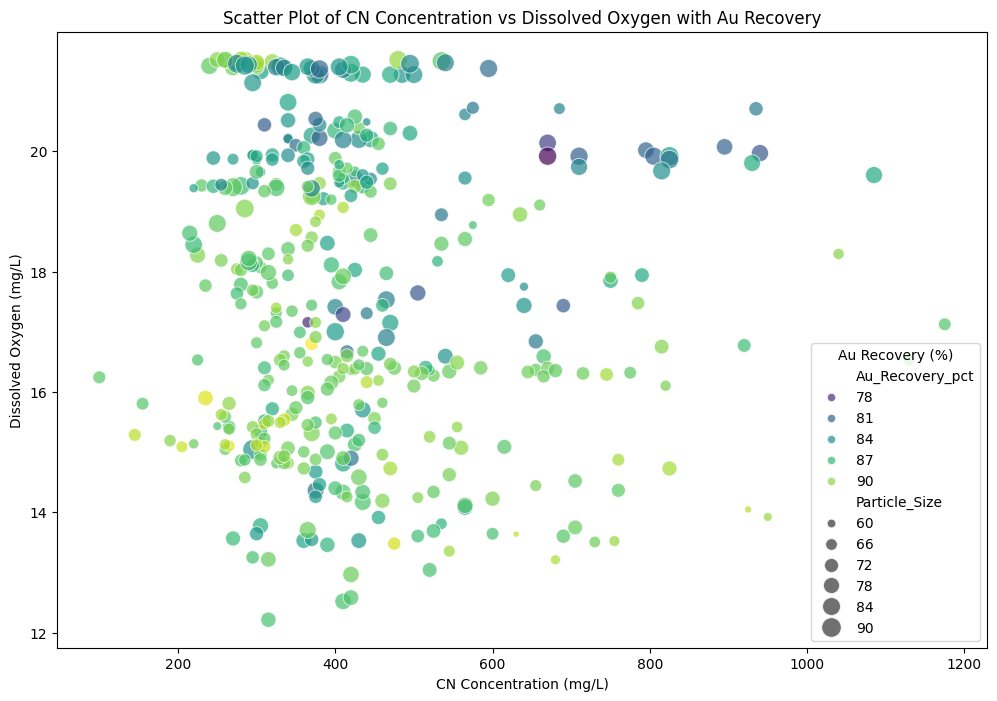

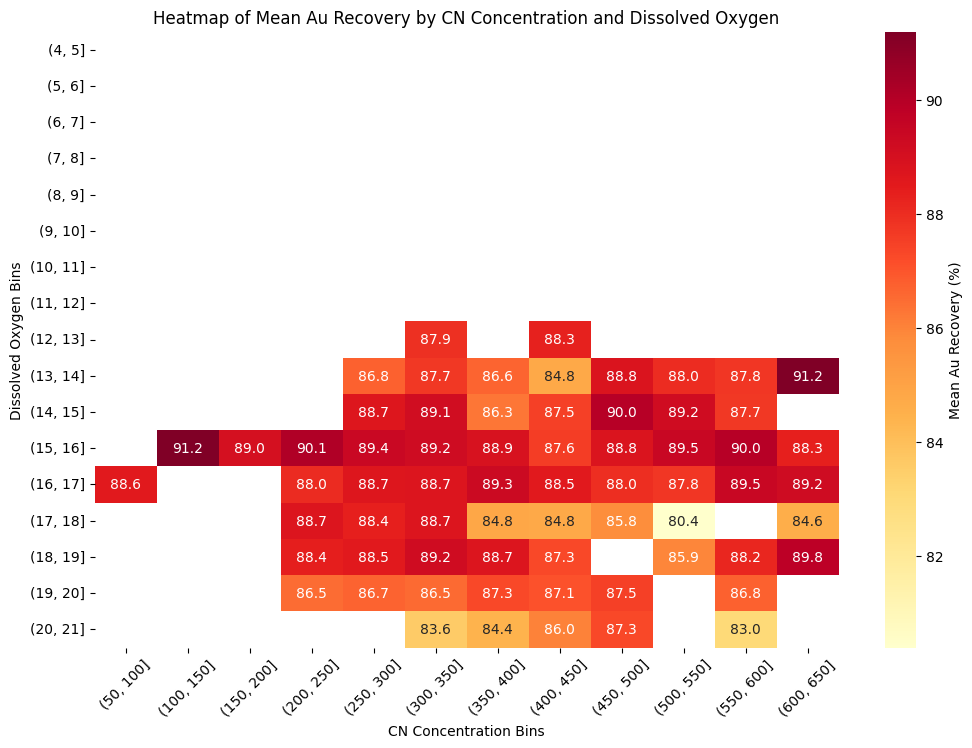

In [2]:
df_filtered = df[
        (df["Fines_Fraction"] >= 50.0) & 
        (df["Fines_Fraction"] <= 90.0)
    ].copy()

df_filtered["CN_Bin"] = pd.cut(df_filtered["CN_Concentration_PL_01"], bins=np.arange(50, 700, 50))
df_filtered["DO_Bin"] = pd.cut(df_filtered["Dissolved_Oxygen_PL_01"], bins=np.arange(4, 22, 1))

df_filtered.groupby(["CN_Bin", "DO_Bin"], observed=False).agg(
            Count=("Au_Recovery_pct", "count"),
            Median_Recovery=("Au_Recovery_pct", "median"),
            Mean_Recovery=("Au_Recovery_pct", "mean"),
            Avg_Particle_Size=("Particle_Size", "mean")
        ).reset_index()

# Plot binned data
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_filtered,
    x="CN_Concentration_PL_01",
    y="Dissolved_Oxygen_PL_01",
    hue="Au_Recovery_pct",
    size="Particle_Size",
    sizes=(20, 200),
    alpha=0.7,
    palette="viridis"
)
plt.title("Scatter Plot of CN Concentration vs Dissolved Oxygen with Au Recovery")
plt.xlabel("CN Concentration (mg/L)")
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.legend(title="Au Recovery (%)")
plt.grid(False)
plt.show()

# Generate Heatmap
plt.figure(figsize=(12, 8))
heatmap_data = df_filtered.groupby(["CN_Bin", "DO_Bin"], observed=False).agg(
    Mean_Recovery=("Au_Recovery_pct", "mean"),
    Count=("Au_Recovery_pct", "count")
).reset_index()
heatmap_pivot = heatmap_data.pivot(index="DO_Bin", columns="CN_Bin", values="Mean_Recovery")
sns.heatmap(heatmap_pivot, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Mean Au Recovery (%)'})
plt.title("Heatmap of Mean Au Recovery by CN Concentration and Dissolved Oxygen")
plt.xlabel("CN Concentration Bins")
plt.ylabel("Dissolved Oxygen Bins")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## Plotly Implementation

In [20]:
# Generate Heatmap with Plotly
import plotly.express as px
heatmap_fig = px.imshow(
    heatmap_pivot.values,
    labels=dict(x="CN Concentration Bins", y="Dissolved Oxygen Bins", color="Mean Au Recovery (%)"),
    x=[str(c) for c in heatmap_pivot.columns],
    y=[str(r) for r in heatmap_pivot.index],
    color_continuous_scale="YlOrRd",
    title="Heatmap of Mean Au Recovery by CN Concentration and Dissolved Oxygen"
)

heatmap_fig.update_layout(
    width=800,
    height=600,
    yaxis=dict(scaleanchor=None),
    xaxis=dict(scaleanchor=None),
    title_font=dict(size=20, color="rgba(255, 255, 255, 0.8)"),
    xaxis_title_font=dict(size=16, color="rgba(255, 255, 255, 0.8)"),
    yaxis_title_font=dict(size=16, color="rgba(255, 255, 255, 0.8)"),
    legend_title_font=dict(size=12, color="rgba(255, 255, 255, 0.8)"),
    coloraxis_colorbar=dict(
        title=dict(
            text="Au Recovery (%)",
            font=dict(size=14, color="rgba(255, 255, 255, 0.8)")
        ),
        tickfont=dict(size=12, color="rgba(255, 255, 255, 0.5)"),
        ticks="outside",
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
)
heatmap_fig.update_xaxes(
    tickfont=dict(size=12, color="rgba(255, 255, 255, 0.5)"),
    gridcolor="rgba(255, 255, 255, 0.1)"
)
heatmap_fig.update_yaxes(
    tickfont=dict(size=12, color="rgba(255, 255, 255, 0.5)"),
    gridcolor="rgba(255, 255, 255, 0.1)"
)
heatmap_fig.show()


# Do the same plot using Plotly
import plotly.express as px
fig = px.scatter(
    df_filtered,
    x="CN_Concentration_PL_01",
    y="Dissolved_Oxygen_PL_01",
    color_continuous_scale="YlOrRd",
    color="Au_Recovery_pct",
    size="Particle_Size",
    hover_name="Date",
    title="Scatter Plot of CN Concentration vs Dissolved Oxygen with Au Recovery",
    labels={
        "CN_Concentration_PL_01": "CN Concentration (mg/L)",
        "Dissolved_Oxygen_PL_01": "Dissolved Oxygen (mg/L)",
        "Au_Recovery_pct": "Au Recovery (%)"
    }
)
fig.update_traces(marker=dict(opacity=0.7, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    width=800,
    height=600,
    yaxis=dict(scaleanchor=None),
    xaxis=dict(scaleanchor=None),
    title_font=dict(
        size=20,
        color="rgba(255, 255, 255, 0.8)"
        ),
    xaxis_title_font=dict(size=14, color="rgba(255, 255, 255, 0.8)"),
    yaxis_title_font=dict(size=14, color="rgba(255, 255, 255, 0.8)"),
    legend_title_font=dict(size=12, color="rgba(255, 255, 255, 0.8)"),
    coloraxis_colorbar=dict(
        title=dict(
            text="Au Recovery (%)",
            font=dict(size=14, color="rgba(255, 255, 255, 0.8)")
        ),
        tickfont=dict(size=12, color="rgba(255, 255, 255, 0.5)"),
        ticks="outside",
    ),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)
fig.update_xaxes(
    tickfont=dict(size=12, color="rgba(255, 255, 255, 0.5)"),
    gridcolor="rgba(255, 255, 255, 0.1)"
)
fig.update_yaxes(
    tickfont=dict(size=12, color="rgba(255, 255, 255, 0.5)"),
    gridcolor="rgba(255, 255, 255, 0.1)"
)
fig.show()